# Chi phí và thời gian theo loại stage cho nhiều query

Nhập `QUERIES` rồi Run All. Hình gồm 2 hàng × N cột: hàng 1 = thời gian, hàng 2 = chi phí; mỗi cột một query, mỗi hệ (No BF, BF-S3, BF-NFS) một cột chồng theo loại stage: scan, BF, join, agg.

- Loại của một stage lấy theo `func` của stage gốc (`step5-lineitem--combine` tính vào scan); stage `--mergebf` và `--…make-bf` tính vào BF.
- `BF_OVERHEAD = "merge+probe"`: phần thời gian BF bên trong từng stage (dựng BF ở combine, tải + kiểm tra BF ở scan/join) theo `model_t_bf` được tách sang BF; chi phí tách theo tỉ lệ `t_bf / thời gian function` trên phần compute. `"merge"` = chỉ stage mergebf/make-bf (đúng số đo).
- Thời gian = tổng thời gian các stage (Runner chạy tuần tự nên bằng critical path).

Dữ liệu: `report.json` do `cost_model_batch.py` sinh ra, chọn run median như `stage_charts-v0.ipynb`. Hình lưu vào `<REPORT>/stages/` (`.pdf` + `.png`).

In [27]:
QUERIES = ["q2", "q9", "q20", "q21"]    # N query, mỗi query một cột
REPORT  = "cost-report/tpch100-v5"
RUN     = "median"                     # "median" = run có T đo ở giữa, hoặc số run 1, 2, …
SYSTEMS = ["base", "s3", "nfs"]        # base = No BF

## Style và dữ liệu

In [28]:
import os, re, json, glob, statistics
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from datetime import datetime
%matplotlib inline

fm.fontManager.addfont("./fonts/LinLibertine_R.otf")
plt.rcParams['font.family'] = 'Linux Libertine O'
plt.rcParams['font.serif'] = ['Linux Libertine O']
FONT_SIZE = 15
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['lines.linewidth'] = 0.8

plt.rcParams.update({
    "axes.grid": True, "legend.frameon": False,
    "axes.spines.top": True, "axes.spines.right": True,      # khung 4 cạnh
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 200, "savefig.bbox": "tight",
})
plt.rcParams.update({                 # số mũ trục log (10¹) và ký hiệu toán cũng dùng Libertine thay vì DejaVu Sans
    "mathtext.fontset": "custom", "mathtext.rm": "Linux Libertine O",
    "mathtext.it": "Linux Libertine O", "mathtext.bf": "Linux Libertine O", "axes.unicode_minus": True,
})
neg = lambda s: s.replace("-", "\u2212")   # dấu trừ thật (−) cho các nhãn số tự định dạng
INK, INK2, GRID = "#000000", "#52514e", "#e4e3df"
plt.rcParams.update({"axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                     "grid.color": GRID})
plt.rcParams.update({"text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black", "legend.labelcolor": "black"})  # chữ đen toàn bộ
LABEL = {"base": "No BF", "s3": "BF + S3 shuffle", "nfs": "BF + NFS shuffle"}
COLOR = {"base": "#2a78d6", "s3": "#eb6834", "nfs": "#1baf7a"}
COST_UNIT, COST_SCALE = "¢", 100      # đơn vị chi phí: ("¢", 100) cent, ("m\\$", 1e3) milli-dollar, ("µ\\$", 1e6)
cost_fmt = lambda usd: f"{usd * COST_SCALE:,.2f}{COST_UNIT}"
OUT = os.path.join(REPORT, "stages")
os.makedirs(OUT, exist_ok=True)

SOURCE  = "meas"                         # "meas" = thực đo, "model" = model
CATS    = ["scan", "BF build", "join", "agg"]   # thứ tự từ dưới lên
BF_OVERHEAD = "merge+probe"              # "merge" = BF build chỉ gồm stage mergebf/make-bf (đúng số đo)
                                         # "merge+probe" = thêm phần dựng/tải/kiểm tra BF trong từng stage (model_t_bf)
CAT_COLOR = {"scan": "#8ecdf2", "BF build": "#ef8c34", "join": "#4a5568", "agg": "#cbd2de"}
FUNC_CAT  = {"scan": "scan", "broadcast_join": "join", "hash_join": "join", "aggregate": "agg"}


def load(query, system, run=RUN):
    """Stages (DataFrame theo thứ tự pipeline) của run được chọn và nhãn run."""
    prefix, side = ("s3", "nobf") if system == "base" else (system, "bf")
    paths = glob.glob(os.path.join(REPORT, query, f"{prefix}-run*", "report.json"))
    reps = {int(p.split("-run")[-1].split(os.sep)[0]): json.load(open(p))["runs"][side] for p in paths}
    if run == "median":
        T = {i: r["totals"]["T_meas"] for i, r in reps.items()}
        i = min(T, key=lambda k: (T[k] != statistics.median_low(T.values()), k))
    else:
        i = int(run)
    return pd.DataFrame(reps[i]["stages"]), f"run {i}/{len(reps)}"


def stage_cat(name, func_of):
    """Loại stage: BF build cho mergebf/make-bf, còn lại theo func của stage gốc (trước '--')."""
    if "--" in name and ("mergebf" in name or "make-bf" in name):
        return "BF build"
    return FUNC_CAT.get(func_of[name.split("--")[0]], "agg")


def by_type(st):
    """Tổng T (s) và C (đơn vị COST_UNIT) theo loại stage."""
    col_d, col_C = ("meas_d_wall", "meas_C") if SOURCE == "meas" else ("model_d", "model_C")
    func_of = dict(zip(st["stage"], st["func"]))
    df = pd.DataFrame({"T": st[col_d], "C": st[col_C] * COST_SCALE, "cat": st["stage"].map(lambda v: stage_cat(v, func_of))})
    if BF_OVERHEAD == "merge+probe":
        # model_t_bf = thời gian BF trong mỗi function; wall của stage giảm đúng chừng đó (các function chạy song song),
        # chi phí giảm theo tỉ lệ t_bf / thời gian function trên phần compute (CC)
        d_fn = st["meas_d_fn"] if SOURCE == "meas" else st["model_d"]
        cc = st["meas_CC"] if SOURCE == "meas" else st["model_CC"]
        bf_T = st["model_t_bf"].clip(upper=df["T"]).where(df["cat"] != "BF build", 0)
        bf_C = (cc * (st["model_t_bf"] / d_fn.where(d_fn > 0)).clip(upper=1).fillna(0) * COST_SCALE).clip(upper=df["C"]).where(df["cat"] != "BF build", 0)
        moved = pd.DataFrame({"T": bf_T, "C": bf_C, "cat": "BF build"})
        df = pd.concat([df.assign(T=df["T"] - bf_T, C=df["C"] - bf_C), moved])
    return df.groupby("cat").sum().reindex(CATS).fillna(0)


AGG = {}
for q in QUERIES:
    for s in SYSTEMS:
        st, tag = load(q, s)
        AGG[q, s] = by_type(st)
        print(f"{q:4} {LABEL[s]:18} {tag:9} T {AGG[q, s]['T'].sum():6.2f}s  C {AGG[q, s]['C'].sum():7.3f}{COST_UNIT}")

q2   No BF              run 6/15  T   6.47s  C   0.419¢
q2   BF + S3 shuffle    run 15/15 T   3.86s  C   0.118¢
q2   BF + NFS shuffle   run 15/15 T   3.09s  C   0.070¢
q9   No BF              run 13/15 T  75.71s  C  24.048¢
q9   BF + S3 shuffle    run 14/15 T  27.37s  C   7.081¢
q9   BF + NFS shuffle   run 12/15 T  34.09s  C   4.075¢
q20  No BF              run 9/15  T  35.51s  C   7.928¢
q20  BF + S3 shuffle    run 8/15  T  10.23s  C   1.389¢
q20  BF + NFS shuffle   run 15/15 T   9.02s  C   1.160¢
q21  No BF              run 6/15  T  53.06s  C  15.593¢
q21  BF + S3 shuffle    run 13/15 T  56.52s  C  13.455¢
q21  BF + NFS shuffle   run 5/15  T  63.92s  C   8.960¢


## Hình: hàng 1 = thời gian, hàng 2 = chi phí, mỗi cột một query

saved cost-report/tpch100-v5/stages/stagetype-q2-q9-q20-q21-meas-merge-probe


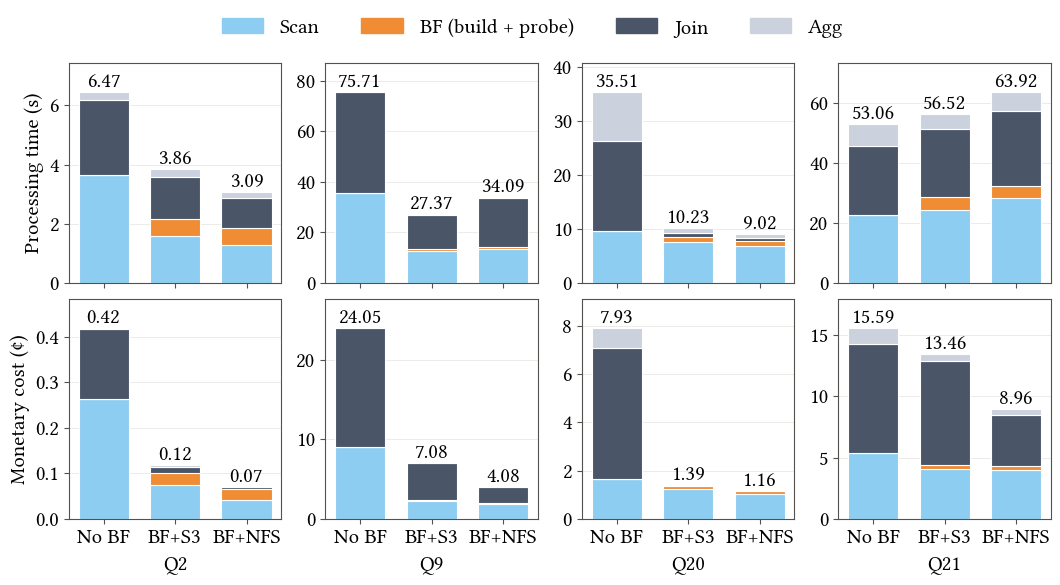

In [29]:
TITLE   = None                           # ví dụ "Cost & time per stage type"; None để bỏ
COL_TITLE = "{query}"                    # tên query của mỗi cột; {query} tự điền (Q2, Q9, …)
COL_TITLE_POS = "bottom"                 # "bottom" = dưới nhãn hệ của hàng cuối, "top" = trên hàng đầu
YLABEL_T = "Processing time (s)"
YLABEL_C = f"Monetary cost ({COST_UNIT})"
BAR_W   = 0.7
SHOW_TOTAL = True                        # ghi tổng trên đầu cột
TOTAL_FMT = "{:.2f}"
XLABEL  = {"base": "No BF", "s3": "BF+S3", "nfs": "BF+NFS"}
XTICK_ROT = 0                            # góc xoay nhãn hệ; 30 nếu nhãn bị dính
LEGEND  = "top"                          # "top" = một hàng phía trên hình, "first" = trong subplot đầu tiên
LEGEND_LOC = "upper right"               # chỉ dùng khi LEGEND = "first"
SUBFIG_W, SUBFIG_H = 2.6, 2.6            # kích thước mỗi subplot (inch)
FIGSIZE = None                           # None = tự tính theo số query
W_PAD, H_PAD = 0.3, 0.2                  # khoảng cách giữa các subplot theo ngang / dọc (đơn vị cỡ chữ; mặc định matplotlib ≈ 1.08)

n = len(QUERIES)
fig, axes = plt.subplots(2, n, figsize=FIGSIZE or (SUBFIG_W * n + 0.5, SUBFIG_H * 2 + 0.4), squeeze=False)
for j, q in enumerate(QUERIES):
    for i, (key, yl) in enumerate((("T", YLABEL_T), ("C", YLABEL_C))):
        ax = axes[i, j]
        for k, s in enumerate(SYSTEMS):
            bottom = 0
            for c in CATS:
                v = AGG[q, s].loc[c, key]
                ax.bar(k, v, BAR_W, bottom=bottom, color=CAT_COLOR[c], edgecolor="white", lw=0.8, zorder=2)
                bottom += v
            if SHOW_TOTAL:
                ax.text(k, bottom, TOTAL_FMT.format(bottom), ha="center", va="bottom", fontsize=FONT_SIZE, color=INK)
        ax.set_ylim(0, max(AGG[q, s][key].sum() for s in SYSTEMS) * 1.15)
        ax.set_xticks(range(len(SYSTEMS)), [XLABEL[s] for s in SYSTEMS] if i == 1 else [], rotation=XTICK_ROT, ha="right" if XTICK_ROT else "center", rotation_mode="anchor", fontsize=FONT_SIZE)
        ax.tick_params(axis="y", labelsize=FONT_SIZE)
        ax.grid(axis="x", visible=False)
        if j == 0:
            ax.set_ylabel(yl)
        if COL_TITLE and i == 0 and COL_TITLE_POS == "top":
            ax.set_title(COL_TITLE.format(query=q.upper()), color=INK)
        if COL_TITLE and i == 1 and COL_TITLE_POS == "bottom":
            ax.set_xlabel(COL_TITLE.format(query=q.upper()), color=INK, labelpad=6)

cat_label = lambda c: "BF (build + probe)" if c == "BF build" and BF_OVERHEAD == "merge+probe" else c[:1].upper() + c[1:]
handles = [Patch(color=CAT_COLOR[c], label=cat_label(c)) for c in CATS]
fig.tight_layout(w_pad=W_PAD, h_pad=H_PAD)
if LEGEND == "top":
    top = max(a.get_position().y1 for a in axes[0]) + FONT_SIZE * (1.6 if COL_TITLE and COL_TITLE_POS == "top" else 0.3) / 72 / fig.get_figheight()
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, top), ncol=len(CATS), fontsize=FONT_SIZE)
else:
    axes[0, 0].legend(handles=handles[::-1], loc=LEGEND_LOC, fontsize=FONT_SIZE)

if TITLE:
    fig.suptitle(TITLE, x=1, ha="left", fontsize=FONT_SIZE, color=INK, y=-1)

name = f"stagetype-{'-'.join(QUERIES)}-{SOURCE}-{BF_OVERHEAD.replace('+', '-')}"
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUT, f"{name}.{ext}"))
print("saved", os.path.join(OUT, name))
plt.show()

## Bảng số liệu

In [30]:
pd.concat({(q.upper(), LABEL[s]): AGG[q, s] for q in QUERIES for s in SYSTEMS}, axis=1).round(3)

Q2                                                            Q9  \
          No BF        BF + S3 shuffle        BF + NFS shuffle          No BF   
              T      C               T      C                T      C       T   
cat                                                                             
scan      3.637  0.263           1.579  0.075            1.272  0.042  35.442   
BF build  0.000  0.000           0.578  0.024            0.580  0.024   0.000   
join      2.549  0.153           1.429  0.015            1.020  0.003  39.985   
agg       0.280  0.003           0.271  0.003            0.213  0.001   0.280   

                                         ...             Q20         \
                 BF + S3 shuffle         ... BF + S3 shuffle          
               C               T      C  ...               T      C   
cat                                      ...                          
scan       8.992          12.506  2.301  ...           7.511  1.260   
BF build   0.000           0.759  0.100  ...           1.026  0.111   
join      14.980          13.809  4.601  ...           0.776  0.009   
agg        0.077           0.293  0.079  ...           0.919  0.009   

                                     Q21                                \
         BF + NFS shuffle          No BF        BF + S3 shuffle          
                        T      C       T      C               T      C   
cat                                                                      
scan                6.836  1.044  22.852  5.360          24.283  4.064   
BF build            1.034  0.112   0.000  0.000           4.439  0.328   
join                0.504  0.002  23.052  8.881          22.661  8.525   
agg                 0.649  0.002   7.159  1.351           5.134  0.538   

                                  
         BF + NFS shuffle         
                        T      C  
cat                               
scan               28.225  3.963  
BF build            4.284  0.333  
join               24.979  4.142  
agg                 6.435  0.523  

[4 rows x 24 columns]